Sample period: 2016-03-10 00:00:00 to 2025-12-30 00:00:00
Observations: 1906


,BTC,ETH
Date,,
2016-03-10,415.8,11.75
2016-03-14,414.3,12.50
2016-03-15,415.1,13.06
2016-03-16,415.9,12.88
2016-03-17,418.2,10.74


,BTC,ETH
Date,,
2025-12-18,85510.1,2828.61
2025-12-22,88547.2,3007.61
2025-12-23,87467.9,2964.86
2025-12-29,87217.7,2938.75
2025-12-30,88469.6,2974.63



Returns shape: (1905, 2)


,BTC,ETH
Date,,
2016-03-14,-0.003614,0.061875
2016-03-15,0.001929,0.043825
2016-03-16,0.001925,-0.013878
2016-03-17,0.005515,-0.181701
2016-03-21,-0.017123,0.106756



Descriptive statistics


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
BTC,1905.0,0.002814,0.048575,-0.497278,-0.016448,0.001738,0.022659,0.234530,-0.501718,9.984725
ETH,1905.0,0.002905,0.068721,-0.589639,-0.025491,0.000514,0.032532,0.470004,-0.264572,10.757284


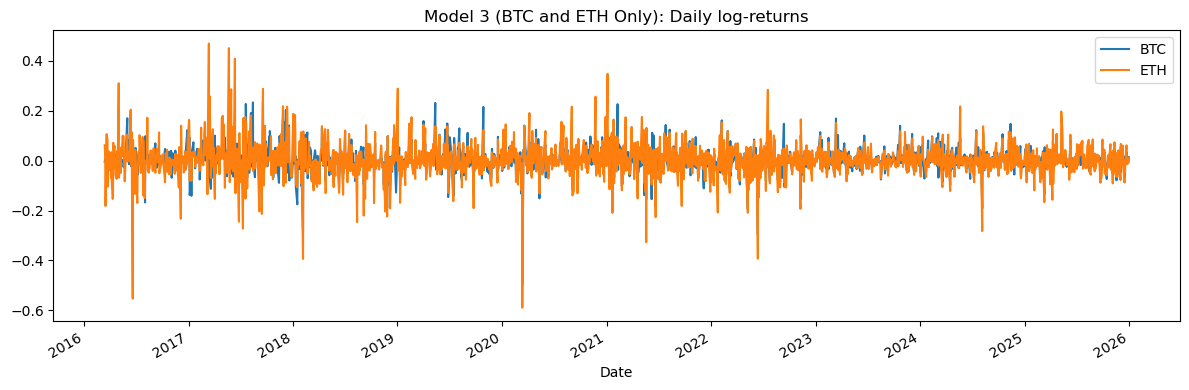

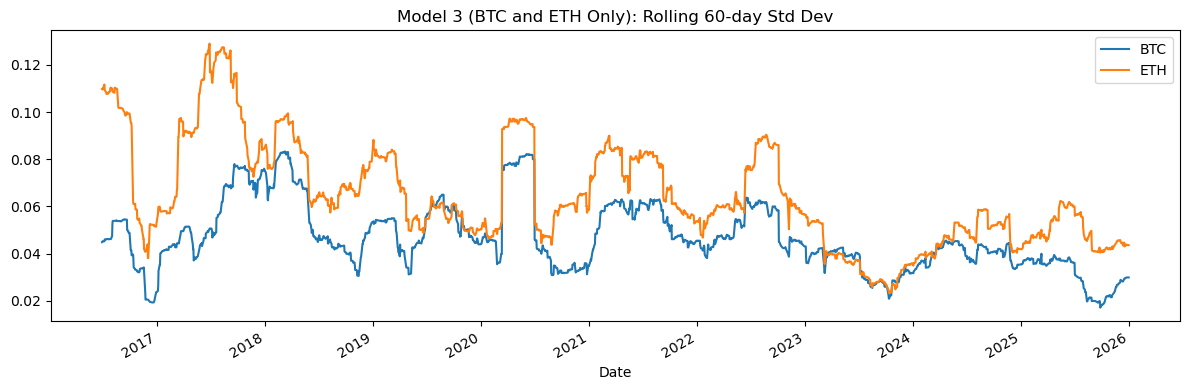


Diagnostics (FULL sample)


,ADF stat,ADF p,LB(20) p (ret),LB(20) p (ret^2),ARCH-LM p,JB p
asset,,,,,,
BTC,-43.9027,0.0,0.3000,0.0105,0.0191,0.0
ETH,-12.5368,0.0,0.0598,0.0010,0.0276,0.0



Univariate GARCH(1,1) fitted for: ['BTC', 'ETH']

DCC (FULL sample) — alpha: 0.0312 | beta: 0.9639 | alpha+beta: 0.9952


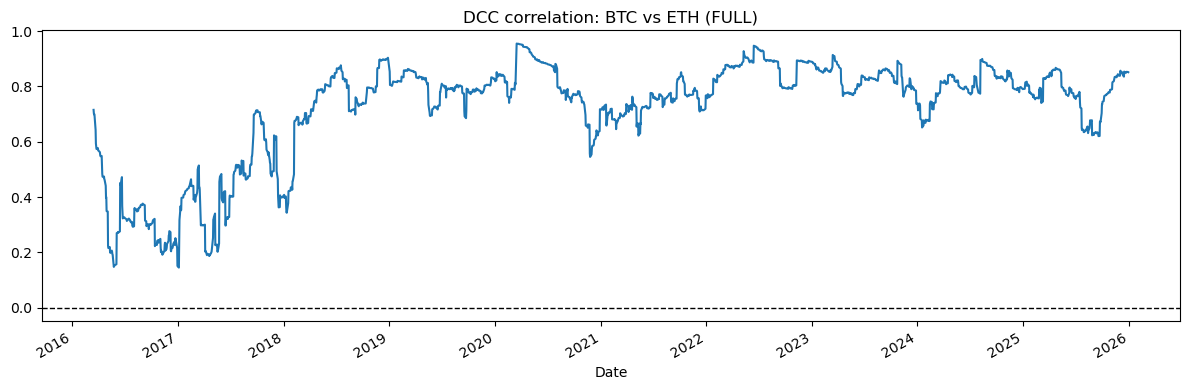


Diebold–Yilmaz (FULL sample) — TSI: 0.09


,BTC,ETH
BTC,99.88,0.12
ETH,0.06,99.94


,FROM,TO,NET
BTC,0.12,0.06,-0.06
ETH,0.06,0.12,0.06


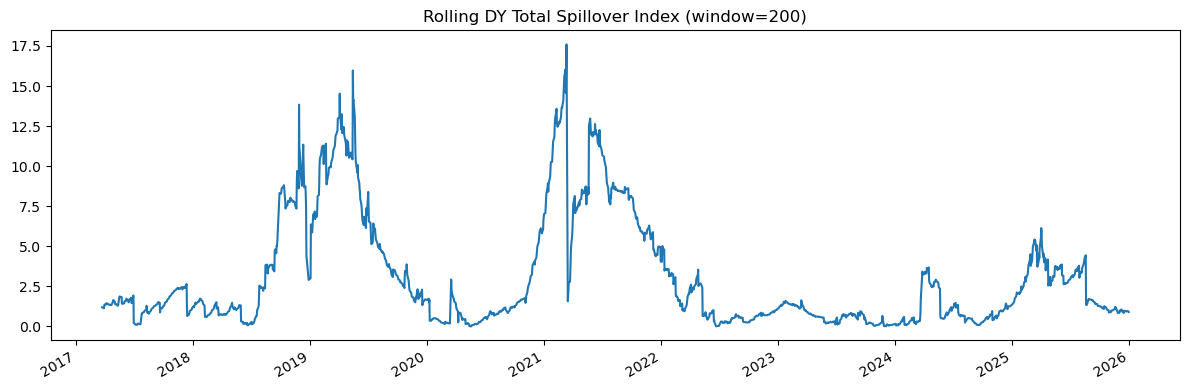


==================== FULL ====================
Obs: 1905 | 2016-03-14 to 2025-12-30
  BEKK BTC–ETH: converged
DCC alpha: 0.0312 | beta: 0.9639 | alpha+beta: 0.9952
DY TSI: 0.09

==================== 2016-2018 ====================
Obs: 545 | 2016-03-14 to 2018-12-27
  BEKK BTC–ETH: converged
DCC alpha: 0.0419 | beta: 0.9547 | alpha+beta: 0.9965
DY TSI: 0.25

==================== 2019-2021 ====================
Obs: 591 | 2019-01-02 to 2021-12-30
  BEKK BTC–ETH: converged
DCC alpha: 0.0215 | beta: 0.9694 | alpha+beta: 0.9910
DY TSI: 0.27

==================== 2022-2025 ====================
Obs: 769 | 2022-01-03 to 2025-12-30
  BEKK BTC–ETH: converged
DCC alpha: 0.0524 | beta: 0.6957 | alpha+beta: 0.7482
DY TSI: 0.20


In [2]:
# MODEL 3 (BTC AND ETH ONLY)
# Subperiods + Diagnostics + (BEKK, DCC, Diebold–Yilmaz)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import het_arch, acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera
from statsmodels.tsa.api import VAR

from arch import arch_model
from scipy.optimize import minimize

import warnings
warnings.filterwarnings("ignore")

# ── CONFIG ────────────────────────────────────────────────────────────────────
MODEL_NAME  = "Model 3 (BTC and ETH Only)"
file_path   = r"C:\Users\Tom Jonkers\OneDrive\HSLU\Semester 4\Thesis\Data\2. Data Model 3.xlsx"

price_assets = ["BTC", "ETH"]

# ETH data begins mid-2016; FULL sample starts 2016-01-01
subperiods = {
    "FULL":      ("2016-01-01", "2025-12-31"),
    "2016-2018": ("2016-01-01", "2018-12-31"),
    "2019-2021": ("2019-01-01", "2021-12-31"),
    "2022-2025": ("2022-01-01", "2025-12-31"),
}

DY_VAR_LAGS    = 1
DY_H           = 10
DY_ROLL_WINDOW = 200
ROLL_STD_WINDOW = 60

# One unique pair only (BTC–ETH is symmetric; no need to repeat reversed)
bekk_pairs = [
    ("BTC", "ETH"),
]

# ── 1) LOAD DATA ──────────────────────────────────────────────────────────────
df = pd.read_excel(file_path)
df["Date"] = pd.to_datetime(df["Date"])
df = df.set_index("Date").sort_index()

print("Sample period:", df.index.min(), "to", df.index.max())
print("Observations:", df.shape[0])
display(df.head())
display(df.tail())

# ── 2) RETURN CONSTRUCTION ────────────────────────────────────────────────────
returns = pd.DataFrame(index=df.index)

for a in price_assets:
    returns[a] = np.log(df[a] / df[a].shift(1))

returns = returns.dropna()
print("\nReturns shape:", returns.shape)
display(returns.head())

# ── 3) PRELIMINARY ANALYSIS ───────────────────────────────────────────────────
desc = returns.describe().T
desc["skew"]     = returns.skew()
desc["kurtosis"] = returns.kurtosis()
print("\nDescriptive statistics")
display(desc)

returns.plot(title=f"{MODEL_NAME}: Daily log-returns", figsize=(12, 4))
plt.tight_layout()
plt.show()

rolling_std = returns.rolling(ROLL_STD_WINDOW).std()
rolling_std.plot(title=f"{MODEL_NAME}: Rolling {ROLL_STD_WINDOW}-day Std Dev", figsize=(12, 4))
plt.tight_layout()
plt.show()

# ── 4) STATISTICAL DIAGNOSTICS ───────────────────────────────────────────────
def diagnostics_table(ret: pd.DataFrame, lb_lags: int = 20) -> pd.DataFrame:
    out = []
    for col in ret.columns:
        x = ret[col].dropna()
        adf_stat, adf_p, *_ = adfuller(x)
        lb_ret_p = acorr_ljungbox(x,    lags=[lb_lags], return_df=True)["lb_pvalue"].iloc[0]
        lb_sq_p  = acorr_ljungbox(x**2, lags=[lb_lags], return_df=True)["lb_pvalue"].iloc[0]
        _, arch_p, *_ = het_arch(x)
        jb_stat, jb_p, *_ = jarque_bera(x)
        out.append({
            "asset": col,
            "ADF stat": round(adf_stat, 4),
            "ADF p": round(adf_p, 4),
            f"LB({lb_lags}) p (ret)": round(lb_ret_p, 4),
            f"LB({lb_lags}) p (ret^2)": round(lb_sq_p, 4),
            "ARCH-LM p": round(arch_p, 4),
            "JB p": round(jb_p, 4),
        })
    return pd.DataFrame(out).set_index("asset")

print("\nDiagnostics (FULL sample)")
diag_full = diagnostics_table(returns, lb_lags=20)
display(diag_full)

# ── 5) UNIVARIATE GARCH(1,1) ─────────────────────────────────────────────────
def fit_univariate_garch(ret: pd.DataFrame, scale: float = 100.0):
    cond_vol  = pd.DataFrame(index=ret.index)
    std_resid = pd.DataFrame(index=ret.index)
    fits = {}
    for col in ret.columns:
        m   = arch_model(ret[col] * scale, mean="Constant", vol="GARCH", p=1, q=1, dist="normal")
        res = m.fit(disp="off")
        fits[col]      = res
        cond_vol[col]  = res.conditional_volatility
        std_resid[col] = res.std_resid
    return fits, cond_vol, std_resid

garch_fits, conditional_vol, standardized_resids = fit_univariate_garch(returns, scale=100.0)
print("\nUnivariate GARCH(1,1) fitted for:", list(returns.columns))

# ── 6) DCC-GARCH ─────────────────────────────────────────────────────────────
def fit_dcc(std_resids: pd.DataFrame, init=(0.05, 0.90)) -> dict:
    Z     = std_resids.dropna().values
    T, N  = Z.shape
    Q_bar = np.cov(Z.T)

    def dcc_obj(params):
        a, b = params
        if a <= 0 or b <= 0 or a + b >= 1:
            return 1e10
        Q_t = Q_bar.copy()
        ll  = 0.0
        for t in range(T):
            if t > 0:
                z_prev = Z[t-1][:, None]
                Q_t = (1 - a - b) * Q_bar + a * (z_prev @ z_prev.T) + b * Q_t
            diag_sqrt_inv = 1.0 / np.sqrt(np.diag(Q_t))
            R_t   = Q_t * np.outer(diag_sqrt_inv, diag_sqrt_inv)
            detR  = np.linalg.det(R_t)
            if detR <= 0 or np.isnan(detR):
                return 1e10
            invR  = np.linalg.inv(R_t)
            z_t   = Z[t][:, None]
            ll += np.log(detR) + float(z_t.T @ invR @ z_t)
        return ll

    res = minimize(dcc_obj, np.array(init),
                   bounds=[(1e-6, 1 - 1e-6), (1e-6, 1 - 1e-6)],
                   method="L-BFGS-B")
    a_hat, b_hat = res.x

    Q_t    = Q_bar.copy()
    R_list = []
    for t in range(T):
        if t > 0:
            z_prev = Z[t-1][:, None]
            Q_t = (1 - a_hat - b_hat) * Q_bar + a_hat * (z_prev @ z_prev.T) + b_hat * Q_t
        diag_sqrt_inv = 1.0 / np.sqrt(np.diag(Q_t))
        R_t = Q_t * np.outer(diag_sqrt_inv, diag_sqrt_inv)
        R_list.append(R_t)

    R_series = np.array(R_list)
    idx      = std_resids.dropna().index
    cols     = std_resids.columns
    dcc_corr = {
        (cols[i], cols[j]): pd.Series(R_series[:, i, j], index=idx)
        for i in range(N) for j in range(i + 1, N)
    }
    return {"alpha": a_hat, "beta": b_hat, "dcc_correlations": dcc_corr}

dcc_full = fit_dcc(standardized_resids)
print(f"\nDCC (FULL sample) — alpha: {dcc_full['alpha']:.4f} | "
      f"beta: {dcc_full['beta']:.4f} | "
      f"alpha+beta: {dcc_full['alpha'] + dcc_full['beta']:.4f}")
dcc_correlations = dcc_full["dcc_correlations"]

example_pair = ("BTC", "ETH")
if example_pair in dcc_correlations:
    dcc_correlations[example_pair].plot(
        title=f"DCC correlation: {example_pair[0]} vs {example_pair[1]} (FULL)", figsize=(12, 4))
    plt.axhline(0, linewidth=1, color="black", linestyle="--")
    plt.tight_layout()
    plt.show()

# ── 7) DIEBOLD–YILMAZ (Generalized FEVD) ─────────────────────────────────────
def generalized_fevd(var_res, H: int = 10) -> np.ndarray:
    Sigma_u = var_res.sigma_u.values
    N       = Sigma_u.shape[0]
    irfs    = var_res.irf(H).irfs
    theta   = np.zeros((N, N))
    for i in range(N):
        denom = sum((irfs[h] @ Sigma_u @ irfs[h].T)[i, i] for h in range(H))
        for j in range(N):
            sigma_jj = Sigma_u[j, j]
            numer    = sum(irfs[h][i, j]**2 * sigma_jj for h in range(H))
            theta[i, j] = numer / denom if denom > 0 else np.nan
    row_sums = theta.sum(axis=1, keepdims=True)
    return theta / row_sums

def dy_spillover(vol_series: pd.DataFrame, var_lags: int = 1, H: int = 10):
    data  = vol_series.dropna()
    res   = VAR(data).fit(var_lags)
    theta = generalized_fevd(res, H=H)
    cols  = data.columns
    tsi         = 100 * (theta.sum() - np.trace(theta)) / theta.sum()
    from_others = (theta.sum(axis=1) - np.diag(theta)) * 100
    to_others   = (theta.sum(axis=0) - np.diag(theta)) * 100
    net         = to_others - from_others
    table   = pd.DataFrame(theta * 100, index=cols, columns=cols)
    summary = pd.DataFrame({"FROM": from_others, "TO": to_others, "NET": net}, index=cols)
    return table, tsi, summary

def dy_rolling_tsi(vol_series: pd.DataFrame, window: int = 200,
                   var_lags: int = 1, H: int = 10) -> pd.Series:
    data = vol_series.dropna()
    out, idx = [], []
    for end in range(window, len(data) + 1):
        sub = data.iloc[end - window:end]
        try:
            _, tsi, _ = dy_spillover(sub, var_lags=var_lags, H=H)
            out.append(tsi)
        except Exception:
            out.append(np.nan)
        idx.append(sub.index[-1])
    return pd.Series(out, index=idx, name="TSI")

dy_table_full, dy_tsi_full, dy_summary_full = dy_spillover(
    conditional_vol, var_lags=DY_VAR_LAGS, H=DY_H)
print(f"\nDiebold–Yilmaz (FULL sample) — TSI: {dy_tsi_full:.2f}")
display(dy_table_full.round(2))
display(dy_summary_full.round(2))

tsi_roll = dy_rolling_tsi(conditional_vol, window=DY_ROLL_WINDOW,
                           var_lags=DY_VAR_LAGS, H=DY_H)
tsi_roll.plot(title=f"Rolling DY Total Spillover Index (window={DY_ROLL_WINDOW})",
              figsize=(12, 4))
plt.tight_layout()
plt.show()

# ── 8) BEKK-GARCH(1,1) bivariate ─────────────────────────────────────────────
def fit_bekk_bivariate(x: pd.DataFrame, scale: float = 100.0, maxiter: int = 2000) -> dict:
    """
    Bivariate BEKK(1,1): H_t = C'C + A' eps_{t-1} eps_{t-1}' A + B' H_{t-1} B
    """
    X  = (x.dropna() * scale).values
    T  = X.shape[0]
    mu = X.mean(axis=0)
    E  = X - mu
    S  = np.cov(E.T)

    def unpack(theta):
        C = np.array([[theta[0], 0.0],
                      [theta[1], theta[2]]])
        A = theta[3:7].reshape(2, 2)
        B = theta[7:11].reshape(2, 2)
        return C, A, B

    def negloglik(theta):
        C, A, B = unpack(theta)
        H  = S.copy()
        ll = 0.0
        CC = C @ C.T
        for t in range(T):
            if t > 0:
                e_prev = E[t-1][:, None]
                H = CC + A.T @ (e_prev @ e_prev.T) @ A + B.T @ H @ B
            detH = np.linalg.det(H)
            if detH <= 0 or np.isnan(detH):
                return 1e12
            invH = np.linalg.inv(H)
            e_t  = E[t][:, None]
            ll  += np.log(detH) + float(e_t.T @ invH @ e_t)
        return ll

    chol   = np.linalg.cholesky(S + 1e-8 * np.eye(2))
    theta0 = np.concatenate([
        [chol[0, 0], chol[1, 0], chol[1, 1]],
        (np.eye(2) * 0.05).flatten(),
        (np.eye(2) * 0.90).flatten(),
    ])
    res = minimize(negloglik, theta0, method="L-BFGS-B",
                   options={"maxiter": maxiter})
    if not res.success:
        raise RuntimeError(res.message)

    C, A, B = unpack(res.x)
    spill = {
        "A_12": A[0, 1], "A_21": A[1, 0],
        "B_12": B[0, 1], "B_21": B[1, 0],
        "shock_spill_1<-2": abs(A[0, 1]),
        "shock_spill_2<-1": abs(A[1, 0]),
        "vol_spill_1<-2":   abs(B[0, 1]),
        "vol_spill_2<-1":   abs(B[1, 0]),
    }
    return {"mu": mu, "C": C, "A": A, "B": B, "spill": spill, "opt": res}

# ── 9) SUBPERIOD LOOP ─────────────────────────────────────────────────────────
results = {}

for name, (start, end) in subperiods.items():
    sub_ret = returns.loc[start:end]
    if len(sub_ret) < 300:
        print(f"\n{name}: skipped (only {len(sub_ret)} obs — minimum 300 required)")
        continue

    print(f"\n{'='*20} {name} {'='*20}")
    print(f"Obs: {len(sub_ret)} | {sub_ret.index.min().date()} to {sub_ret.index.max().date()}")

    diag = diagnostics_table(sub_ret, lb_lags=20)
    _, sub_vol, sub_std = fit_univariate_garch(sub_ret, scale=100.0)
    dcc_out = fit_dcc(sub_std)
    dy_tbl, dy_tsi, dy_sum = dy_spillover(sub_vol, var_lags=DY_VAR_LAGS, H=DY_H)

    bekk_out = {}
    for a, b in bekk_pairs:
        Xpair = sub_ret[[a, b]].dropna()
        if len(Xpair) < 400:
            print(f"  BEKK {a}–{b}: skipped (only {len(Xpair)} obs)")
            continue
        try:
            fit = fit_bekk_bivariate(Xpair, scale=100.0, maxiter=1500)
            bekk_out[(a, b)] = fit["spill"]
            print(f"  BEKK {a}–{b}: converged")
        except Exception as e:
            bekk_out[(a, b)] = {"error": str(e)}
            print(f"  BEKK {a}–{b}: FAILED — {e}")

    results[name] = {
        "diagnostics":    diag,
        "dcc_alpha":      dcc_out["alpha"],
        "dcc_beta":       dcc_out["beta"],
        "dcc_corr":       dcc_out["dcc_correlations"],
        "dy_tsi":         dy_tsi,
        "dy_table":       dy_tbl,
        "dy_summary":     dy_sum,
        "bekk_spillovers": bekk_out,
    }
    print(f"DCC alpha: {dcc_out['alpha']:.4f} | beta: {dcc_out['beta']:.4f} | "
          f"alpha+beta: {dcc_out['alpha'] + dcc_out['beta']:.4f}")
    print(f"DY TSI: {dy_tsi:.2f}")



1. DATA & SAMPLE DEFINITION


,Item,Value
0,Sample start date,2016-03-14
1,Sample end date,2025-12-30
2,Number of observations,1905
3,Assets included,"BTC, ETH"


,Label,Period,Key in results
0,FULL,2016–2025,FULL
1,2016–2018,2016–2018,2016-2018
2,2019–2021,2019–2021,2019-2021
3,2022–2025,2022–2025,2022-2025



2. RETURN CONSTRUCTION & PRELIMINARY EVIDENCE


,Mean,Std. Dev.,Skewness,Kurtosis
BTC,0.002814,0.048575,-0.501718,9.984725
ETH,0.002905,0.068721,-0.264572,10.757284


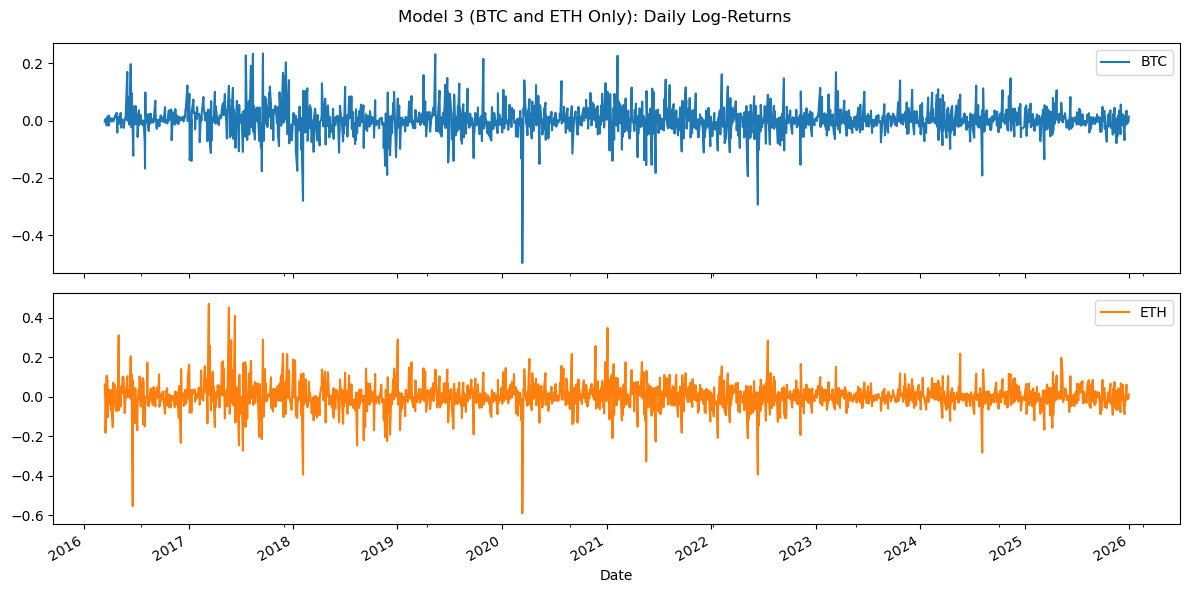

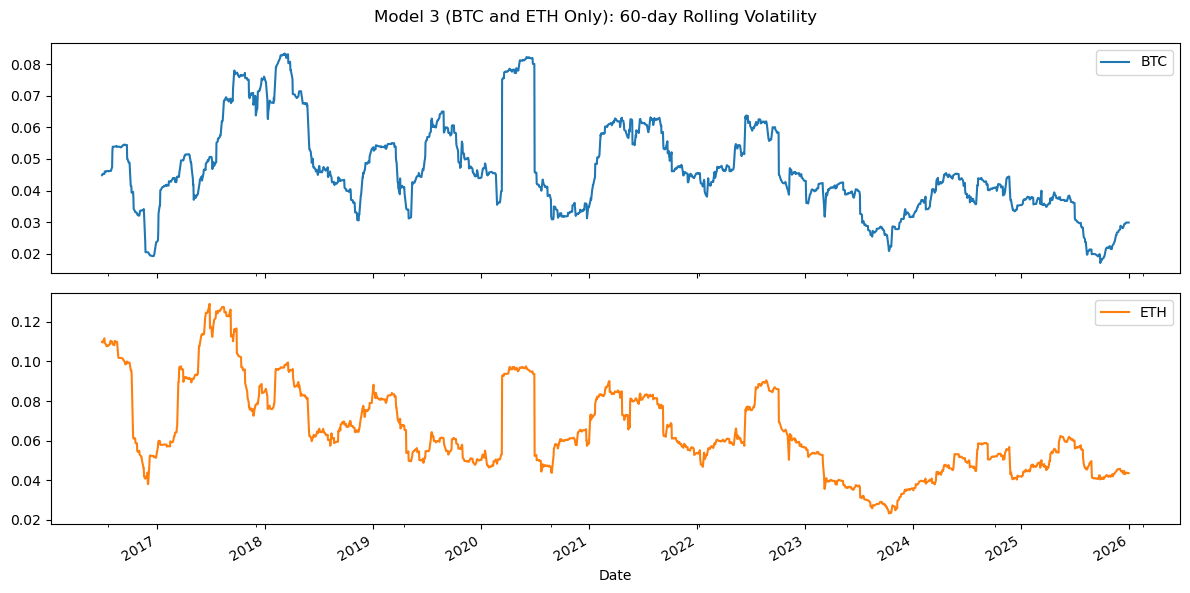


3. STATISTICAL DIAGNOSTICS (FULL SAMPLE)


,ADF stat,ADF p,LB(20) p (ret),LB(20) p (ret^2),ARCH-LM p,JB p
asset,,,,,,
BTC,-43.9027,0.0,0.3000,0.0105,0.0191,0.0
ETH,-12.5368,0.0,0.0598,0.0010,0.0276,0.0



4. UNIVARIATE GARCH(1,1)


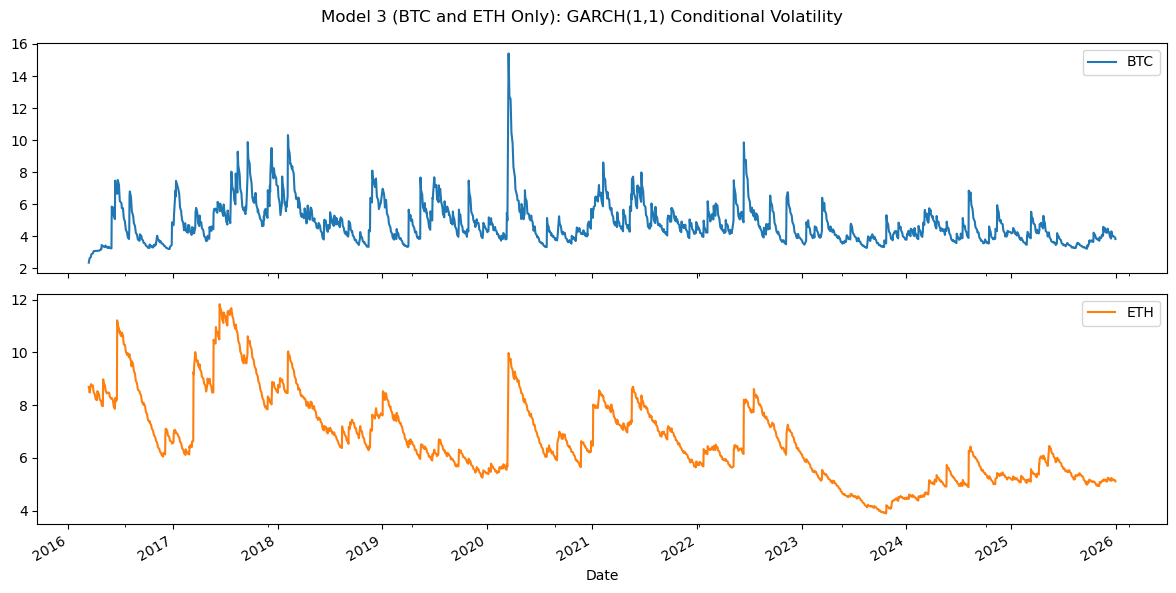

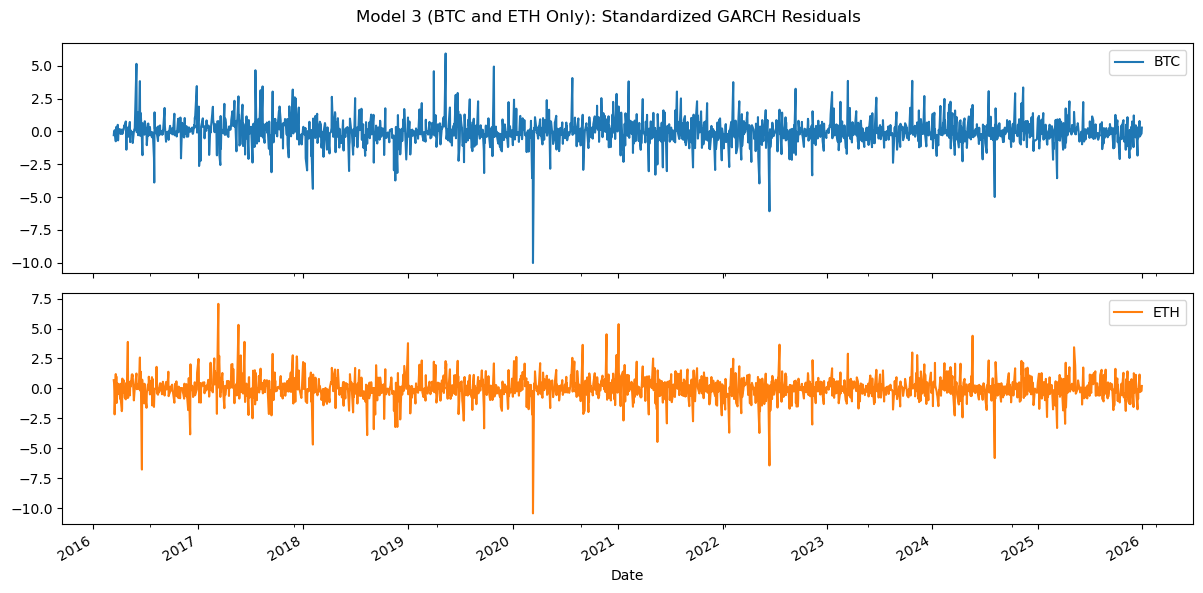


5. DCC-GARCH — DYNAMIC CORRELATIONS


,alpha,beta,alpha+beta
FULL,0.0312,0.9639,0.9952
2016-2018,0.0419,0.9547,0.9965
2019-2021,0.0215,0.9694,0.9910
2022-2025,0.0524,0.6957,0.7482


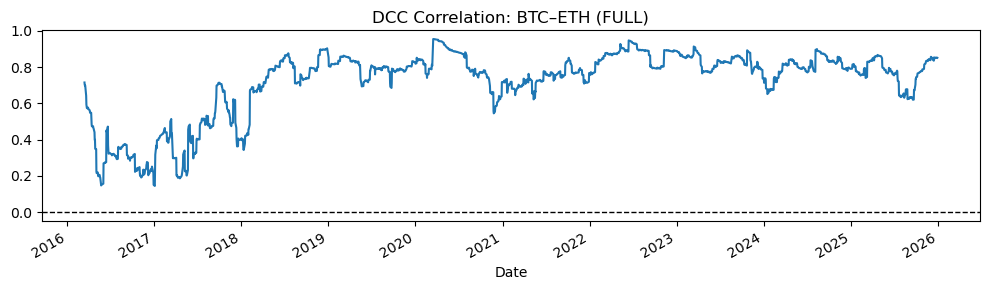

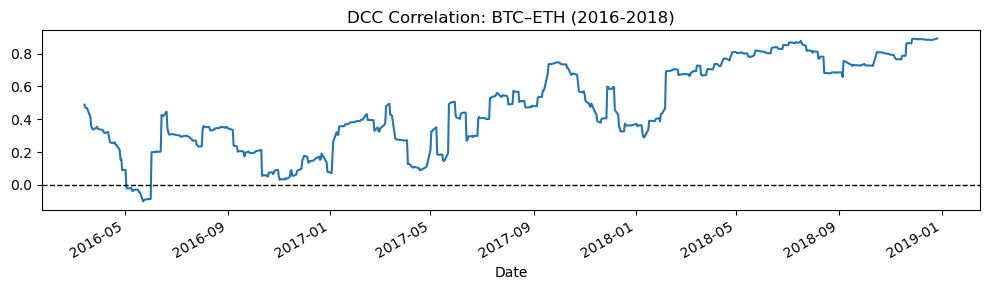

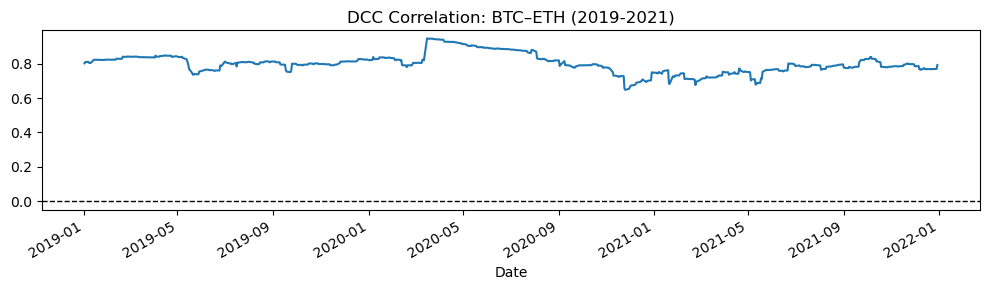

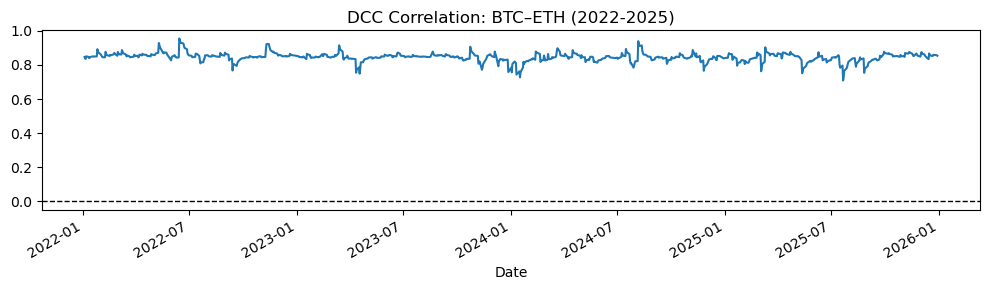


6. DIEBOLD–YILMAZ CONNECTEDNESS

--- FULL ---
Spillover Matrix (GFEVD, row-normalised, ×100)


,BTC,ETH
BTC,99.88,0.12
ETH,0.06,99.94


Directional Connectedness


,FROM,TO,NET
BTC,0.12,0.06,-0.06
ETH,0.06,0.12,0.06


Total Spillover Index (TSI): 0.09

--- 2016-2018 ---
Spillover Matrix (GFEVD, row-normalised, ×100)


...

Total Spillover Index (TSI): 0.27

--- 2022-2025 ---
Spillover Matrix (GFEVD, row-normalised, ×100)


,BTC,ETH
BTC,99.79,0.21
ETH,0.19,99.81


Directional Connectedness


,FROM,TO,NET
BTC,0.21,0.19,-0.03
ETH,0.19,0.21,0.03


Total Spillover Index (TSI): 0.20


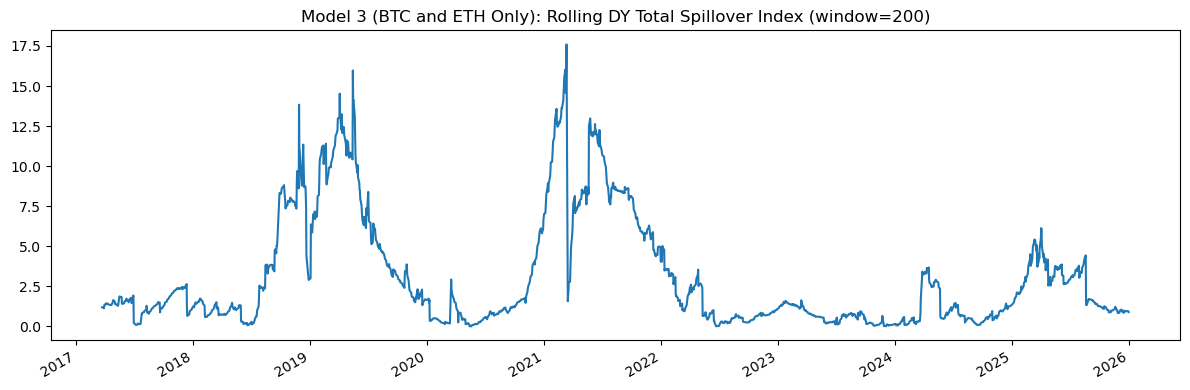


7. BEKK-GARCH — DIRECTIONAL VOLATILITY SPILLOVERS

BEKK Spillovers — FULL


,Pair,Shock 1←2,Shock 2←1,Vol 1←2,Vol 2←1
0,BTC–ETH,0.0098,0.0323,1.8402,0.2764



BEKK Spillovers — 2016-2018


,Pair,Shock 1←2,Shock 2←1,Vol 1←2,Vol 2←1
0,BTC–ETH,0.1245,0.0104,1.7856,0.3344



BEKK Spillovers — 2019-2021


,Pair,Shock 1←2,Shock 2←1,Vol 1←2,Vol 2←1
0,BTC–ETH,0.003,0.0025,0.0309,0.0032



BEKK Spillovers — 2022-2025


,Pair,Shock 1←2,Shock 2←1,Vol 1←2,Vol 2←1
0,BTC–ETH,0.2632,0.0596,1.6926,0.1653


In [3]:
# RESULTS OUTPUT — MODEL 3 (BTC AND ETH ONLY)

import pandas as pd
import matplotlib.pyplot as plt

MODEL_NAME = "Model 3 (BTC and ETH Only)"

# ── 1. DATA & SAMPLE DEFINITION ───────────────────────────────────────────────
print("\n" + "="*30)
print("1. DATA & SAMPLE DEFINITION")
print("="*30)

display(pd.DataFrame({
    "Item":  ["Sample start date", "Sample end date",
              "Number of observations", "Assets included"],
    "Value": [returns.index.min().date(), returns.index.max().date(),
              len(returns), ", ".join(returns.columns)],
}))

display(pd.DataFrame({
    "Label":  ["FULL", "2016–2018", "2019–2021", "2022–2025"],
    "Period": ["2016–2025", "2016–2018", "2019–2021", "2022–2025"],
    "Key in results": ["FULL", "2016-2018", "2019-2021", "2022-2025"],
}))

# ── 2. RETURN CONSTRUCTION & PRELIMINARY EVIDENCE ─────────────────────────────
print("\n" + "="*30)
print("2. RETURN CONSTRUCTION & PRELIMINARY EVIDENCE")
print("="*30)

table_2_1 = returns.describe().T[["mean", "std"]]
table_2_1.columns = ["Mean", "Std. Dev."]
table_2_1["Skewness"] = returns.skew()
table_2_1["Kurtosis"] = returns.kurtosis()
display(table_2_1.round(6))

returns.plot(subplots=True, figsize=(12, 6), title=f"{MODEL_NAME}: Daily Log-Returns")
plt.tight_layout()
plt.show()

rolling_std.plot(subplots=True, figsize=(12, 6),
                 title=f"{MODEL_NAME}: 60-day Rolling Volatility")
plt.tight_layout()
plt.show()

# ── 3. STATISTICAL DIAGNOSTICS (FULL SAMPLE) ──────────────────────────────────
print("\n" + "="*30)
print("3. STATISTICAL DIAGNOSTICS (FULL SAMPLE)")
print("="*30)
display(diag_full)

# ── 4. UNIVARIATE GARCH(1,1) ──────────────────────────────────────────────────
print("\n" + "="*30)
print("4. UNIVARIATE GARCH(1,1)")
print("="*30)

conditional_vol.plot(subplots=True, figsize=(12, 6),
                     title=f"{MODEL_NAME}: GARCH(1,1) Conditional Volatility")
plt.tight_layout()
plt.show()

standardized_resids.plot(subplots=True, figsize=(12, 6),
                         title=f"{MODEL_NAME}: Standardized GARCH Residuals")
plt.tight_layout()
plt.show()

# ── 5. DCC-GARCH — DYNAMIC CORRELATIONS ───────────────────────────────────────
print("\n" + "="*30)
print("5. DCC-GARCH — DYNAMIC CORRELATIONS")
print("="*30)

dcc_param_table = pd.DataFrame({
    k: {"alpha": v["dcc_alpha"], "beta": v["dcc_beta"],
        "alpha+beta": v["dcc_alpha"] + v["dcc_beta"]}
    for k, v in results.items()
}).T.round(4)
display(dcc_param_table)

for period, out in results.items():
    for pair, series in out["dcc_corr"].items():
        series.plot(figsize=(10, 3),
                    title=f"DCC Correlation: {pair[0]}–{pair[1]} ({period})")
        plt.axhline(0, linewidth=1, color="black", linestyle="--")
        plt.tight_layout()
        plt.show()

# ── 6. DIEBOLD–YILMAZ CONNECTEDNESS ───────────────────────────────────────────
print("\n" + "="*30)
print("6. DIEBOLD–YILMAZ CONNECTEDNESS")
print("="*30)

for period, out in results.items():
    print(f"\n--- {period} ---")
    print("Spillover Matrix (GFEVD, row-normalised, ×100)")
    display(out["dy_table"].round(2))
    print("Directional Connectedness")
    display(out["dy_summary"].round(2))
    print(f"Total Spillover Index (TSI): {out['dy_tsi']:.2f}")

tsi_roll.plot(figsize=(12, 4),
              title=f"{MODEL_NAME}: Rolling DY Total Spillover Index (window={DY_ROLL_WINDOW})")
plt.tight_layout()
plt.show()

# ── 7. BEKK-GARCH — DIRECTIONAL VOLATILITY SPILLOVERS ────────────────────────
print("\n" + "="*30)
print("7. BEKK-GARCH — DIRECTIONAL VOLATILITY SPILLOVERS")
print("="*30)

def bekk_output_table(results_dict: dict, period: str) -> pd.DataFrame:
    rows = []
    for (a, b), out in results_dict[period]["bekk_spillovers"].items():
        if "error" in out:
            rows.append({"Pair": f"{a}–{b}",
                         "Shock 1←2": "FAILED", "Shock 2←1": "FAILED",
                         "Vol 1←2":   "FAILED", "Vol 2←1":   "FAILED"})
        else:
            rows.append({
                "Pair":      f"{a}–{b}",
                "Shock 1←2": round(out["shock_spill_1<-2"], 4),
                "Shock 2←1": round(out["shock_spill_2<-1"], 4),
                "Vol 1←2":   round(out["vol_spill_1<-2"],   4),
                "Vol 2←1":   round(out["vol_spill_2<-1"],   4),
            })
    return pd.DataFrame(rows)

for period in list(results.keys()):
    print(f"\nBEKK Spillovers — {period}")
    display(bekk_output_table(results, period))
